<a href="https://colab.research.google.com/github/jaiswalsourav/ML-Model-/blob/main/Face_Mask_Detection_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FACE MASK DETECTION**

In [12]:
!pip install kaggle

In [13]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [14]:
# API to fetch the dataset from Kaggle
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 86% 141M/163M [00:00<00:00, 1.47GB/s]
100% 163M/163M [00:00<00:00, 1.43GB/s]


In [15]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [16]:
!ls


data  face-mask-dataset.zip  kaggle.json  sample_data


## **Creating Deposistory**

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [18]:
with_mask_files = os.listdir('/content/data/with_mask')
print(with_mask_files[0:5])
print(with_mask_files[-5:])

['with_mask_1621.jpg', 'with_mask_523.jpg', 'with_mask_2730.jpg', 'with_mask_3295.jpg', 'with_mask_2608.jpg']
['with_mask_1618.jpg', 'with_mask_2117.jpg', 'with_mask_3033.jpg', 'with_mask_3642.jpg', 'with_mask_2262.jpg']


In [19]:
without_mask_files = os.listdir('/content/data/without_mask')
print(without_mask_files[0:5])
print(without_mask_files[-5:])

['without_mask_719.jpg', 'without_mask_1013.jpg', 'without_mask_2103.jpg', 'without_mask_1707.jpg', 'without_mask_451.jpg']
['without_mask_1546.jpg', 'without_mask_1540.jpg', 'without_mask_3703.jpg', 'without_mask_1563.jpg', 'without_mask_1297.jpg']


In [20]:
print('Number of with mask images:', len(with_mask_files))
print('Number of without mask images:', len(without_mask_files))

Number of with mask images: 3725
Number of without mask images: 3828


## Creating Labels for the two class of Images

with mask --> 1

without mask --> 0

In [21]:
# create the labels

with_mask_labels = [1]*3725

without_mask_labels = [0]*3828

In [23]:
print(with_mask_labels[0:5])

print(without_mask_labels[0:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [24]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [25]:
labels = with_mask_labels + without_mask_labels

print(len(labels))
print(labels[0:5])
print(labels[-5:])

7553
[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


## **Display of image**

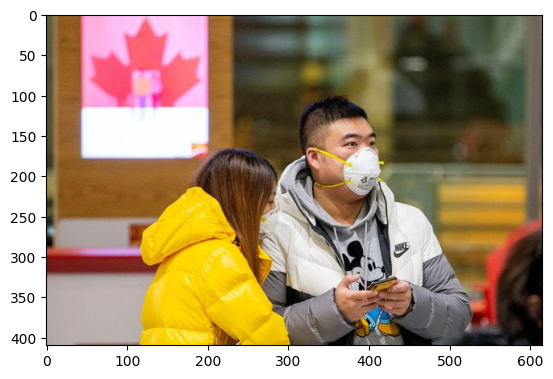

In [26]:
# displaying with mask image
img = mpimg.imread('/content/data/with_mask/with_mask_3500.jpg')
imgplot = plt.imshow(img)
plt.show()

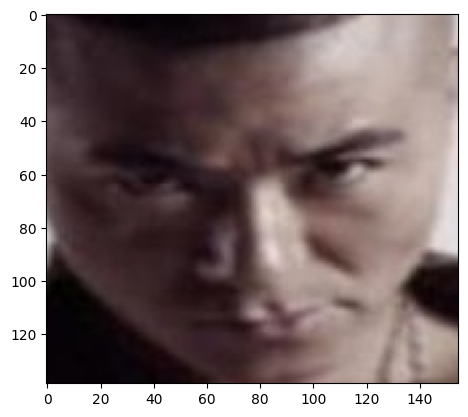

In [27]:
# displaying with mask image
img = mpimg.imread('/content/data/without_mask/without_mask_150.jpg')
imgplot = plt.imshow(img)
plt.show()

## **Image Processing**

1. Resize the Images

2. Convert the images to numpy arrays

In [28]:
# convert images to numpy arrays+

with_mask_path = '/content/data/with_mask/'

data = []

for img_file in with_mask_files:

  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)



without_mask_path = '/content/data/without_mask/'


for img_file in without_mask_files:

  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [29]:
type(data)

list

In [30]:
len(data)

7553

array([[[137,  96,  66],
        [137,  96,  66],
        [128,  89,  58],
        ...,
        [ 59,  73,  60],
        [ 60,  74,  61],
        [ 61,  75,  62]],

       [[148, 101,  71],
        [145,  98,  68],
        [137,  91,  61],
        ...,
        [ 51,  64,  52],
        [ 51,  64,  52],
        [ 52,  65,  53]],

       [[155, 101,  70],
        [150,  97,  65],
        [146,  94,  62],
        ...,
        [ 62,  73,  61],
        [ 58,  69,  58],
        [ 60,  71,  60]],

       ...,

       [[ 13,  21,  21],
        [ 14,  20,  21],
        [ 19,  22,  24],
        ...,
        [ 29,  35,  39],
        [ 29,  34,  40],
        [ 29,  32,  40]],

       [[ 14,  21,  25],
        [ 20,  24,  29],
        [ 25,  27,  32],
        ...,
        [ 24,  33,  36],
        [ 27,  32,  38],
        [ 31,  32,  40]],

       [[ 19,  26,  33],
        [ 24,  29,  36],
        [ 25,  26,  33],
        ...,
        [ 24,  33,  36],
        [ 29,  35,  42],
        [ 36,  35,  44]]], dtype=uint8)
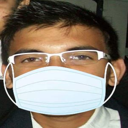

In [31]:
data[0]

In [32]:
type(data[0])

numpy.ndarray

In [33]:
data[0].shape

(128, 128, 3)

In [34]:
# converting image list and label list to numpy arrays

X = np.array(data)
Y = np.array(labels)

In [35]:
type(X)

numpy.ndarray

In [36]:
type(Y)

numpy.ndarray

In [37]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


In [38]:
print(Y)

[1 1 1 ... 0 0 0]


## **Split test and train cases**

In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [40]:
print(X.shape, X_train.shape, X_test.shape)

(7553, 128, 128, 3) (6042, 128, 128, 3) (1511, 128, 128, 3)


In [41]:
# scaling the data

X_train_scaled = X_train/255

X_test_scaled = X_test/255

array([[[ 39,  40,  44],
        [ 39,  40,  44],
        [ 39,  40,  44],
        ...,
        [ 38,  39,  41],
        [ 38,  39,  41],
        [ 38,  39,  41]],

       [[ 39,  40,  44],
        [ 38,  39,  43],
        [ 39,  40,  44],
        ...,
        [ 38,  39,  41],
        [ 38,  39,  41],
        [ 38,  39,  41]],

       [[ 40,  41,  45],
        [ 39,  40,  44],
        [ 39,  40,  44],
        ...,
        [ 37,  38,  40],
        [ 38,  39,  41],
        [ 39,  40,  42]],

       ...,

       [[143, 125, 106],
        [137, 119, 102],
        [130, 113,  97],
        ...,
        [119, 113, 106],
        [130, 111, 106],
        [124, 100,  95]],

       [[147, 126, 107],
        [140, 121, 102],
        [133, 114,  97],
        ...,
        [122, 117, 108],
        [133, 125, 118],
        [124, 113, 106]],

       [[142, 122, 103],
        [136, 117, 100],
        [135, 116,  99],
        ...,
        [134, 132, 120],
        [135, 131, 121],
        [142, 136, 126]]], dtype=uint8)
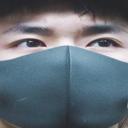

In [35]:
X_train[0]

In [42]:
X_train_scaled[0]

array([[[0.15294118, 0.15686275, 0.17254902],
        [0.15294118, 0.15686275, 0.17254902],
        [0.15294118, 0.15686275, 0.17254902],
        ...,
        [0.14901961, 0.15294118, 0.16078431],
        [0.14901961, 0.15294118, 0.16078431],
        [0.14901961, 0.15294118, 0.16078431]],

       [[0.15294118, 0.15686275, 0.17254902],
        [0.14901961, 0.15294118, 0.16862745],
        [0.15294118, 0.15686275, 0.17254902],
        ...,
        [0.14901961, 0.15294118, 0.16078431],
        [0.14901961, 0.15294118, 0.16078431],
        [0.14901961, 0.15294118, 0.16078431]],

       [[0.15686275, 0.16078431, 0.17647059],
        [0.15294118, 0.15686275, 0.17254902],
        [0.15294118, 0.15686275, 0.17254902],
        ...,
        [0.14509804, 0.14901961, 0.15686275],
        [0.14901961, 0.15294118, 0.16078431],
        [0.15294118, 0.15686275, 0.16470588]],

       ...,

       [[0.56078431, 0.49019608, 0.41568627],
        [0.5372549 , 0.46666667, 0.4       ],
        [0.50980392, 0

**Building a Convolutional Neural Networks (CNN)**

In [43]:
import tensorflow as tf
from tensorflow import keras

In [44]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

In [45]:
# compile the neural network
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])

In [46]:
# training the neural network
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=5)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - acc: 0.7198 - loss: 0.6548 - val_acc: 0.8876 - val_loss: 0.3085
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8802 - loss: 0.2820 - val_acc: 0.8959 - val_loss: 0.2541
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.8907 - loss: 0.2575 - val_acc: 0.9174 - val_loss: 0.2517
Epoch 4/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9213 - loss: 0.2036 - val_acc: 0.9190 - val_loss: 0.2515
Epoch 5/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9381 - loss: 0.1647 - val_acc: 0.9140 - val_loss: 0.2493


## **Model Evaluation**

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

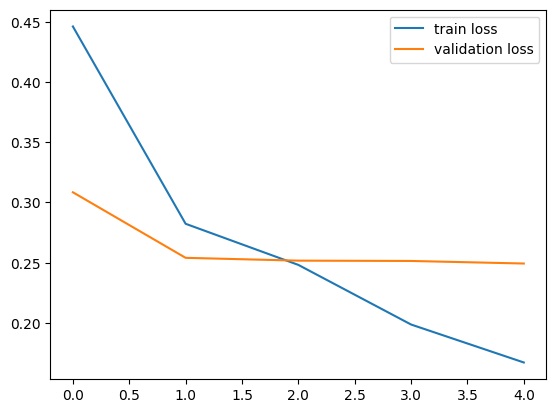

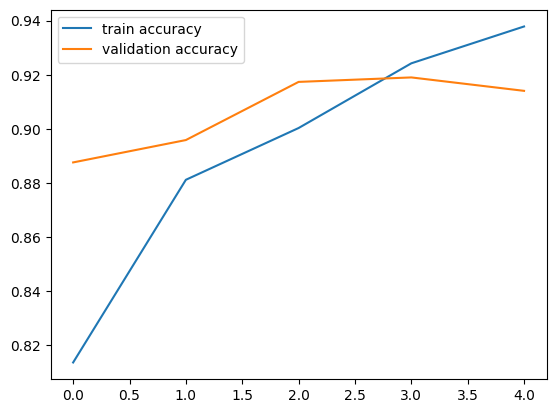

In [48]:
h = history

# plot the loss value
plt.plot(h.history['loss'], label='train loss')
plt.plot(h.history['val_loss'], label='validation loss')
plt.legend()
plt.show()

# plot the accuracy value
plt.plot(h.history['acc'], label='train accuracy')
plt.plot(h.history['val_acc'], label='validation accuracy')
plt.legend()
plt.show()

## **Predection**

Path of the image to be predicted: /content/mask.jpeg


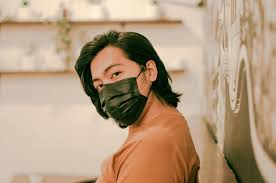

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
[[0.08436897 0.90208155]]
1
The person in the image is wearing a mask


In [51]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/withoutmask.jpeg


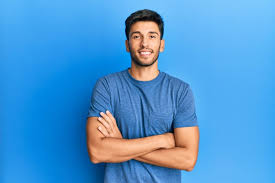

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.4761959 0.4003237]]
0
The person in the image is not wearing a mask


In [62]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')

Path of the image to be predicted: /content/mask.jpeg


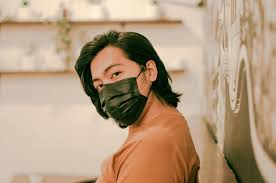

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.08436897 0.90208155]]
1
The person in the image is wearing a mask


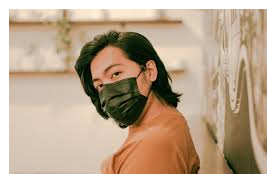

In [61]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized / 255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

# ---------- ADD WHITE THICK BORDER ----------
h, w, _ = input_image.shape
color = (255, 255, 255)   # white
thickness = 15            # thick border

# Draw border around full image
cv2.rectangle(input_image, (0, 0), (w-1, h-1), color, thickness)
# -------------------------------------------

if input_pred_label == 1:
    print('The person in the image is wearing a mask')
else:
    print('The person in the image is not wearing a mask')

cv2_imshow(input_image)
